In [10]:
import pandas as pd

df = pd.read_csv('./employee_data.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   34        No  Travel_Frequently        702  Research & Development   
1   38        No      Travel_Rarely        833  Research & Development   
2   51        No      Travel_Rarely        833  Research & Development   
3   60        No      Travel_Rarely       1179                   Sales   
4   23        No      Travel_Rarely        571  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                16          4  Life Sciences              1             838   
1                18          3        Medical              1            1766   
2                 1          3  Life Sciences              1             353   
3                16          4      Marketing              1             732   
4                12          2          Other              1            1982   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [11]:
print(df.head()['StandardHours'].nunique())
print(df.head()['Over18'].nunique())
print(df.head()['EmployeeCount'].nunique())

df = df.drop(columns=['StandardHours', 'Over18', 'EmployeeCount'])

1
1
1


In [12]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [13]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['overtime_x_experience'] = df['OverTime'].map({'Yes': 1, 'No': -1}) * df['YearsAtCompany']
df['income_per_year_experience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['years_without_promotion_ratio'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['role_tenure_ratio'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1)
df['manager_tenure_ratio'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,overtime_x_experience,income_per_year_experience,years_without_promotion_ratio,role_tenure_ratio,manager_tenure_ratio
0,34,0,Travel_Frequently,702,Research & Development,16,4,Life Sciences,838,3,...,3,5,2,1,3,-5,364.714286,0.166667,0.333333,0.500000
1,38,0,Travel_Rarely,833,Research & Development,18,3,Medical,1766,2,...,3,1,0,1,0,1,363.187500,0.500000,0.000000,0.000000
2,51,0,Travel_Rarely,833,Research & Development,1,3,Life Sciences,353,3,...,2,1,0,0,0,-1,1361.500000,0.000000,0.000000,0.000000
3,60,0,Travel_Rarely,1179,Sales,16,4,Marketing,732,1,...,3,2,2,2,2,-2,491.363636,0.666667,0.666667,0.666667
4,23,0,Travel_Rarely,571,Research & Development,12,2,Other,1982,4,...,4,5,2,1,4,-5,441.166667,0.166667,0.333333,0.666667


In [14]:
churnCount = df['Attrition'].value_counts()
churnCount

Attrition
0    1048
1     201
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import OneHotEncoder

model_df = df.copy()
columns_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
ohe = OneHotEncoder(sparse_output=False)
encoded_data = ohe.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(columns_to_encode))
df = pd.concat([df.drop(columns=columns_to_encode), encoded_df], axis=1)
print(df.columns)

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'overtime_x_experience',
       'income_per_year_experience', 'years_without_promotion_ratio',
       'role_tenure_ratio', 'manager_tenure_ratio',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'Education

In [16]:
df.corrwith(df['Attrition']).sort_values(ascending=False)

Attrition                            1.000000
OverTime_Yes                         0.223517
MaritalStatus_Single                 0.171914
JobRole_Sales Representative         0.142064
overtime_x_experience                0.140095
JobRole_Laboratory Technician        0.128079
income_per_year_experience           0.124671
BusinessTravel_Travel_Frequently     0.113758
DistanceFromHome                     0.085921
Department_Sales                     0.073414
EducationField_Technical Degree      0.050831
EducationField_Marketing             0.050323
EducationField_Human Resources       0.049799
NumCompaniesWorked                   0.046480
JobRole_Human Resources              0.034500
Gender_Male                          0.024300
JobRole_Sales Executive              0.018855
Department_Human Resources           0.015897
MonthlyRate                          0.015846
PerformanceRating                    0.013731
EmployeeNumber                       0.000162
PercentSalaryHike                 

In [17]:
from sklearn.model_selection import train_test_split

model_df = model_df.drop(['EmployeeNumber', 'PercentSalaryHike'], axis=1)

X = model_df.drop('Attrition', axis=1)
y = model_df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

In [18]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

def build_models():
    categorical_columns = X_train.select_dtypes(include=['object']).columns
    numeric_columns = [column for column in X_train.columns if column not in categorical_columns]
    preprocessing = ColumnTransformer([
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('numeric', StandardScaler(), numeric_columns),
    ])
    logistic_model = Pipeline([
        ('preprocessing', preprocessing),
        ('classifier', LogisticRegression(max_iter=3000, class_weight={0: 1, 1: 2}, C=0.1)),
    ])
    xgb_model = Pipeline([
        ('preprocessing', preprocessing),
        ('classifier', XGBClassifier(
            random_state=42,
            max_depth=2,
            learning_rate=0.03,
            n_estimators=400,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_lambda=5,
            reg_alpha=0.2,
            scale_pos_weight=3,
        )),
    ])
    return logistic_model, xgb_model

logistic_model, xgb_model = build_models()
logistic_model.fit(X_fit, y_fit)
xgb_model.fit(X_fit, y_fit)

# Select the threshold only on validation data, keeping test data unseen.
validation_probability = (
    0.6 * logistic_model.predict_proba(X_validation)[:, 1]
    + 0.4 * xgb_model.predict_proba(X_validation)[:, 1]
)
threshold_results = []
for threshold in np.arange(0.20, 0.81, 0.01):
    validation_pred = validation_probability >= threshold
    precision = precision_score(y_validation, validation_pred, zero_division=0)
    recall = recall_score(y_validation, validation_pred)
    if precision >= 0.70:
        threshold_results.append((recall, precision, -threshold))

best_recall, validation_precision, negative_threshold = max(threshold_results)
best_threshold = -negative_threshold
print(f'Selected threshold: {best_threshold:.2f}')
print(f'Validation precision: {validation_precision:.2f}; recall: {best_recall:.2f}')

# Refit on all training data after model and threshold selection.
logistic_model, xgb_model = build_models()
logistic_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
test_probability = (
    0.6 * logistic_model.predict_proba(X_test)[:, 1]
    + 0.4 * xgb_model.predict_proba(X_test)[:, 1]
)
pred = (test_probability >= best_threshold).astype(int)
print(classification_report(y_test, pred))

# Keep a single model-like object available for later use.
model = (logistic_model, xgb_model, best_threshold)

Selected threshold: 0.59
Validation precision: 0.75; recall: 0.37
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       214
           1       0.80      0.56      0.66        36

    accuracy                           0.92       250
   macro avg       0.86      0.77      0.80       250
weighted avg       0.91      0.92      0.91       250



<Axes: >

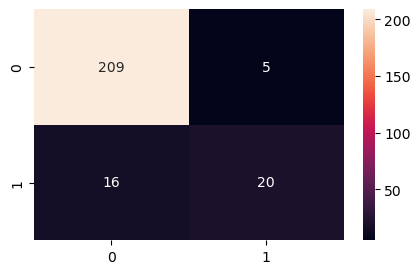

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')